# Marketplace safety

## 1. Dataförståelse & EDA

In [9]:
import pandas as pd


df = pd.read_csv("data/historical_data.csv")
X_full = df.drop(columns="is_suspicious")
y_full = df["is_suspicious"]



print(f"Antal rader och kolumner: {df.shape} \n") #datasetstorlek
print(f"{df.info()} \n") #datatyper
print(f"Antal misstänkta(1)/icke misstänkta(0):\n{df["is_suspicious"].value_counts()}") #targetfördelning


Antal rader och kolumner: (12000, 18) 

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  str    
 3   category                    12000 non-null  str    
 4   region                      11660 non-null  str    
 5   device                      12000 non-null  str    
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  co

In [10]:
print(f"Antal saknade värden: \n{df.isna().sum()}") #enklare överblick över saknade värden

display(df.head())
display(df.describe().T)

Antal saknade värden: 
id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


,count,mean,std,min,25%,50%,75%,max
id,12000.0,5999.500000,3464.245950,0.00,2999.750,5999.500,8999.250,11999.00
day,12000.0,7.482667,4.032520,1.00,4.000,7.000,11.000,14.00
account_age_days,12000.0,99.632567,112.903541,2.20,36.300,66.600,120.700,2741.70
num_prev_listings,12000.0,3.027750,1.766467,0.00,2.000,3.000,4.000,12.00
prev_reports_30d,12000.0,0.151500,0.386083,0.00,0.000,0.000,0.000,3.00
verification_level,12000.0,0.710167,0.719171,0.00,0.000,1.000,1.000,2.00
price,11182.0,207.348603,196.226023,7.67,86.195,149.225,256.795,2743.08
num_images,12000.0,2.870417,1.766886,0.00,2.000,3.000,4.000,10.00
message_length,12000.0,111.154417,66.396885,0.00,63.000,108.000,155.000,416.00
contains_off_platform,12000.0,0.072833,0.259874,0.00,0.000,0.000,0.000,1.00


Text(0.5, 1.0, 'Heatmap / korrelationsmatris')

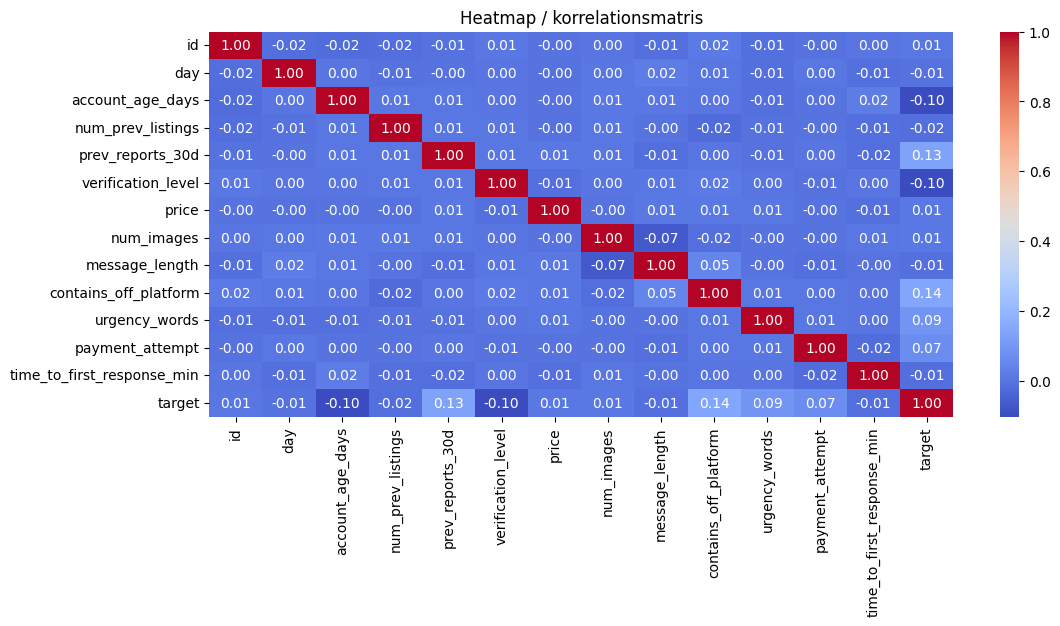

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


df_for_eda = X_full.copy()
df_for_eda["target"] = y_full


correlation_matrix = df_for_eda.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(12,5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.title("Heatmap / korrelationsmatris")

### Korrelationsmatris
Här ser vi att target påverkas mest av "contains_off_platfrom", "prev_reports_30d", "account_age_days", "urgency_words".  
Generellt visar det låg korrelation vilket idikerar att alla bidrar med information.

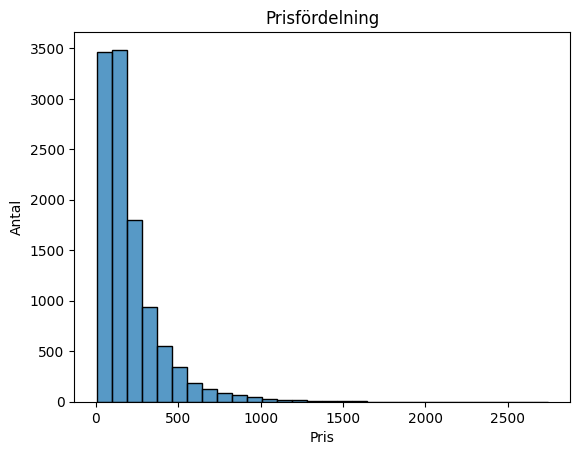

In [12]:
sns.histplot(df["price"], bins=30)
plt.title("Prisfördelning")
plt.xlabel("Pris")
plt.ylabel("Antal")
plt.show()

Grafen visar att medianen är bäst för imputer strategy, för att hantera saknade värden.

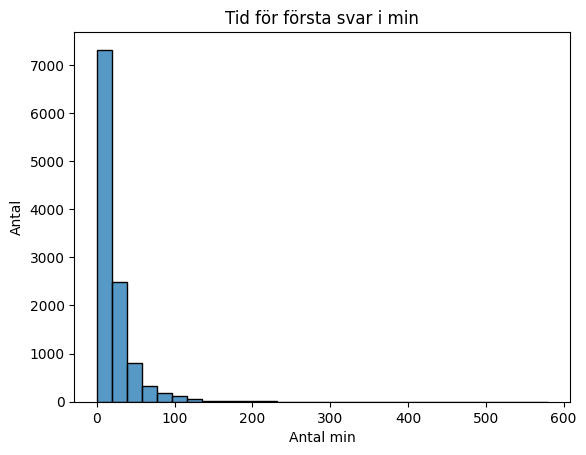

In [13]:
sns.histplot(df["time_to_first_response_min"], bins=30)
plt.title("Tid för första svar i min")
plt.xlabel("Antal min")
plt.ylabel("Antal")
plt.show()

Grafen visar att medianen är bäst för imputer strategy, för att hantera saknade värden.

## 2. Train/test + preprocessing

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

numeric_features = X_full.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_full.select_dtypes(exclude=["number"]).columns.tolist()


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

## 3. Modellering och jämförelse

In [18]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
randforest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
decisiontree = DecisionTreeClassifier(class_weight="balanced", random_state=42)

pipe_logreg = Pipeline([("preprocess", preprocessor), ("model", logreg)])
pipe_randforest = Pipeline([("preprocess", preprocessor), ("model", randforest)])
pipe_decisiontree = Pipeline([("preprocess", preprocessor), ("model", decisiontree)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = "precision"

baseline_rows = []

for name, pipe in [("LogisticRegression", pipe_logreg), ("RandomForest", pipe_randforest), ("DecisionTree", pipe_decisiontree)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=SCORING)
    print(name, scores)
    baseline_rows.append({"model": name, "mean": scores.mean(), "std": scores.std()})

baseline_table = pd.DataFrame(baseline_rows).sort_values("mean", ascending=False)
baseline_table

LogisticRegression [0.18529412 0.19303797 0.19783617 0.18389058 0.19593614]
RandomForest [0.6        0.25       0.42857143 0.5        0.5       ]
DecisionTree [0.18556701 0.16842105 0.14       0.16113744 0.19672131]


,model,mean,std
1,RandomForest,0.455714,0.116444
0,LogisticRegression,0.191199,0.005624
2,DecisionTree,0.170369,0.019681


## 4. Hyperparameter tuning

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid_logreg = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
}

grid_logreg = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid_logreg,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1
)
grid_logreg.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_logreg.cv_results_)
best_row = cv_results.loc[grid_logreg.best_index_]

print("Best params:", grid_logreg.best_params_)
print(f"Mean CV {SCORING}:", round(best_row["mean_test_score"], 3))
print(f"Std CV {SCORING}:", round(best_row["std_test_score"], 3))

Best params: {'model__C': 0.01, 'model__solver': 'lbfgs'}
Mean CV precision: 0.194
Std CV precision: 0.006
